# 04  Residual Connections (MiniChefGPT)

1st residual : around masked multi-head attention  `x = x + Attention(LN(x))` 
 2nd residual : around the feed-forward network `x = x + FFN(LN(x))` 

A residual connection adds the input of a sub-layer back to its output, so each sub-layer only learns a correction instead of rebuilding the representation.
Parts marked STAND-IN are placeholders for teammates' modules until they are merged.

In [1]:
import sys, ast
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.residual import ResidualConnection

torch.manual_seed(42)
np.random.seed(42)
print("torch", torch.__version__, "| root:", ROOT)

torch 2.14.1+cpu | root: c:\Users\user\Downloads\MiniChefGPT


In [2]:
candidates = [ROOT / "data" / "recipes_clean.csv", ROOT / "recipes_clean.csv"]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("recipes_clean.csv not found. Put it in data/ or the repo root.")

df = pd.read_csv(DATA_PATH)
print(DATA_PATH.name, df.shape, list(df.columns))
df.head(3)

recipes_clean.csv (9980, 3) ['title', 'ingredients', 'steps']


,title,ingredients,steps
0,Low-Fat Berry Blue Frozen Dessert,"['blueberries', 'granulated sugar', 'vanilla y...","['Toss 2 cups berries with sugar.', 'Let stand..."
1,Biryani,"['saffron', 'milk', 'hot green chili peppers',...",['Soak saffron in warm milk for 5 minutes and ...
2,Best Lemonade,"['sugar', 'lemons, rind of', 'lemon, zest of',...","['Into a 1 quart Jar with tight fitting lid, p..."


In [3]:
def to_list(cell):
    try:
        v = ast.literal_eval(cell)
        return v if isinstance(v, list) else [str(v)]
    except (ValueError, SyntaxError):
        return [str(cell)]

def format_recipe(row):
    ingredients = ", ".join(to_list(row["ingredients"]))
    steps = " ".join(to_list(row["steps"]))
    return f"Title: {row['title']}\nIngredients: {ingredients}\nInstructions: {steps}"

print(format_recipe(df.iloc[0])[:500])

Title: Low-Fat Berry Blue Frozen Dessert
Ingredients: blueberries, granulated sugar, vanilla yogurt, lemon juice
Instructions: Toss 2 cups berries with sugar. Let stand for 45 minutes, stirring occasionally. Transfer berry-sugar mixture to food processor. Add yogurt and process until smooth. Strain through fine sieve. Pour into baking pan (or transfer to ice cream maker and process according to manufacturers' directions). Freeze uncovered until edges are solid but centre is soft. Transfer to pro


In [4]:
# STAND-IN word-level tokenizer (replace with src.tokenizer / src.embeddings later)
from collections import Counter

texts = [format_recipe(r) for _, r in df.head(500).iterrows()]
words = [w for t in texts for w in t.lower().split()]
common = [w for w, _ in Counter(words).most_common(1999)]
stoi = {w: i + 1 for i, w in enumerate(common)}   # 0 = <unk>
vocab_size = len(stoi) + 1
stream = torch.tensor([stoi.get(w, 0) for w in words], dtype=torch.long)
print("vocab size:", vocab_size, "| tokens:", len(stream))

D_MODEL, N_HEADS, SEQ_LEN, BATCH = 64, 4, 32, 32

def get_batch():
    ix = torch.randint(0, len(stream) - SEQ_LEN - 1, (BATCH,))
    xb = torch.stack([stream[i:i + SEQ_LEN] for i in ix])
    yb = torch.stack([stream[i + 1:i + SEQ_LEN + 1] for i in ix])
    return xb, yb

xb, yb = get_batch()
print("token ids:", tuple(xb.shape), "| targets:", tuple(yb.shape))

vocab size: 2000 | tokens: 55333
token ids: (32, 32) | targets: (32, 32)


In [5]:
B, T, D = 4, SEQ_LEN, D_MODEL
x = torch.randn(B, T, D)
sub = torch.randn(B, T, D)
res = ResidualConnection(dropout=0.0)

out = res(x, sub)
assert out.shape == x.shape
print("(a) shape preserved:", tuple(out.shape))

try:
    res(x, torch.randn(B, T, D + 1))
    raise AssertionError("mismatch was not caught")
except ValueError as e:
    print("(b) mismatch caught:", e)

assert torch.allclose(out, x + sub)
print("(c) output == x + sublayer_output")

assert torch.equal(res(x, torch.zeros_like(x)), x)
print("(d) zero sub-layer returns x unchanged")

res_d = ResidualConnection(dropout=0.5)
res_d.eval()
assert torch.allclose(res_d(x, sub), x + sub)
print("dropout is off in eval mode")

(a) shape preserved: (4, 32, 64)
(b) mismatch caught: Residual shape mismatch: x (4, 32, 64) vs sublayer_output (4, 32, 65)
(c) output == x + sublayer_output
(d) zero sub-layer returns x unchanged
dropout is off in eval mode


In [6]:
class DemoBlock(nn.Module):
    # STAND-IN attention/FFN/LayerNorm; only ResidualConnection is mine.
    def __init__(self, d_model, n_heads, use_residual=True, dropout=0.1):
        super().__init__()
        self.use_residual = use_residual
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(nn.Linear(d_model, 4 * d_model), nn.GELU(), nn.Linear(4 * d_model, d_model))
        self.residual1 = ResidualConnection(dropout)   # 1st residual (attention)
        self.residual2 = ResidualConnection(dropout)   # 2nd residual (FFN)

    def forward(self, x, causal_mask):
        h = self.ln1(x)
        a, _ = self.attn(h, h, h, attn_mask=causal_mask, need_weights=False)
        x = self.residual1(x, a) if self.use_residual else a

        f = self.ffn(self.ln2(x))
        x = self.residual2(x, f) if self.use_residual else f
        return x


class DemoLM(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, use_residual=True, dropout=0.1):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, d_model)
        self.pos = nn.Embedding(SEQ_LEN, d_model)
        self.blocks = nn.ModuleList(
            [DemoBlock(d_model, n_heads, use_residual, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, ids):
        T = ids.shape[1]
        x = self.tok(ids) + self.pos(torch.arange(T, device=ids.device))
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=ids.device), diagonal=1)
        for blk in self.blocks:
            x = blk(x, mask)
        return self.head(self.ln_f(x))


m = DemoLM(vocab_size, D_MODEL, N_HEADS, n_layers=2)
logits = m(xb)
assert logits.shape == (BATCH, SEQ_LEN, vocab_size)
print("2-layer demo model output:", tuple(logits.shape), "(batch, seq_len, vocab)")

2-layer demo model output: (32, 32, 2000) (batch, seq_len, vocab)


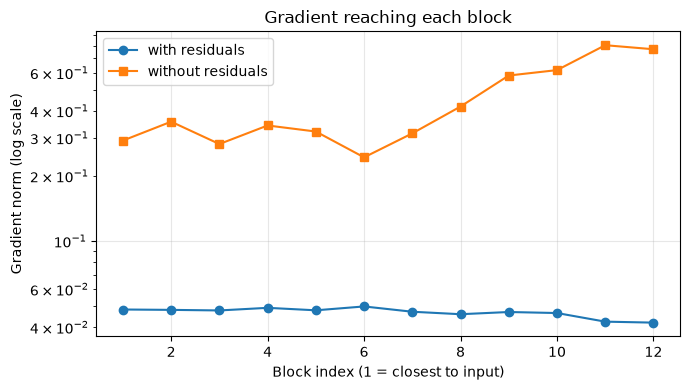

Block 1 gradient  with: 0.04823 | without: 0.29134


In [7]:
def grad_per_layer(use_residual, n_layers=12):
    torch.manual_seed(0)
    model = DemoLM(vocab_size, D_MODEL, N_HEADS, n_layers, use_residual, dropout=0.0)
    model.train()
    xb_, yb_ = get_batch()
    loss = nn.functional.cross_entropy(model(xb_).reshape(-1, vocab_size), yb_.reshape(-1))
    loss.backward()
    return [blk.ffn[0].weight.grad.norm().item() for blk in model.blocks]

g_with = grad_per_layer(True)
g_without = grad_per_layer(False)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 13), g_with, "o-", label="with residuals")
plt.plot(range(1, 13), g_without, "s-", label="without residuals")
plt.yscale("log")
plt.xlabel("Block index (1 = closest to input)")
plt.ylabel("Gradient norm (log scale)")
plt.title("Gradient reaching each block")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("Block 1 gradient  with:", round(g_with[0], 5), "| without:", round(g_without[0], 5))

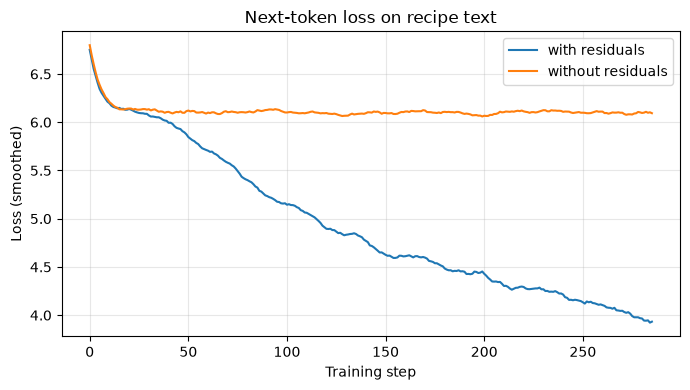

Final loss (avg last 20 steps) | with: 3.968 | without: 6.088


In [8]:
def train(use_residual, n_layers=8, steps=300, lr=3e-3):
    torch.manual_seed(1)
    model = DemoLM(vocab_size, D_MODEL, N_HEADS, n_layers, use_residual, dropout=0.1)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    losses = []
    model.train()
    for step in range(steps):
        xb_, yb_ = get_batch()
        loss = nn.functional.cross_entropy(model(xb_).reshape(-1, vocab_size), yb_.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

loss_with = train(True)
loss_without = train(False)

def smooth(v, k=15):
    return np.convolve(v, np.ones(k) / k, mode="valid")

plt.figure(figsize=(7, 4))
plt.plot(smooth(loss_with), label="with residuals")
plt.plot(smooth(loss_without), label="without residuals")
plt.xlabel("Training step"); plt.ylabel("Loss (smoothed)")
plt.title("Next-token loss on recipe text")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"Final loss (avg last 20 steps) | with: {np.mean(loss_with[-20:]):.3f} | without: {np.mean(loss_without[-20:]):.3f}")

## Explanation

Why two residual connections?    
 A Transformer block has two sub-layers: masked attention (mixes information between tokens) and the feed-forward network (processes each token). Each gets its own skip connection so neither can erase what came before it.

Residual 1: keeps the embedding (which word, which position) alongside what attention adds.
 Residual 2:keeps the attention-enriched representation alongside what the FFN adds.

Role in MiniChefGPT: the residual connection carries each token's representation through the block, so every sub-layer only learns a correction instead of rebuilding the whole representation. This allows several blocks to be stacked and keeps training stable.

What happened without residuals in our experiments: (8-layer stand-in model, real recipe tokens, same seed):
Training loss:with residuals it kept decreasing to about 3.97. Without residuals it stalled at about 6.1 from early in training and did not improve.
Gradients (12 layers): with residuals the gradient norm was small and stable across all blocks (about 0.04–0.05). Without residuals it was larger but uneven from block to block (about 0.24–0.78). Gradient size alone did not predict whether the model could learn.

Caveat: the stand-in blocks use LayerNorm before each sub-layer, which keeps gradients from vanishing at initialization. So the main effect we measured is on training progress, not on vanishing gradients. This is a short CPU run, so it shows the trend rather than final model quality.

Dimension rule: the sub-layer output must have the same shape as its input, `(batch, seq_len, d_model)`. `ResidualConnection` raises a clear `ValueError` if they differ (tested in Cell 6).